In [1]:
import torch
import torch.nn as nn

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [3]:
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

val_dataset = datasets.ImageFolder(
    root="../data/EuroSAT/val",
    transform=val_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print(len(val_dataset))

4050


In [4]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    10
)

In [5]:
model.load_state_dict(
    torch.load(
        "../models/rgb_best.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("Model Loaded")

Model Loaded


In [6]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

In [8]:
import pandas as pd

pred_df = pd.DataFrame({
    "Actual": all_labels,
    "Predicted": all_preds
})

pred_df.to_csv("../results/rgb_predictions.csv", index=False)

print("rgb_predictions.csv saved")

rgb_predictions.csv saved


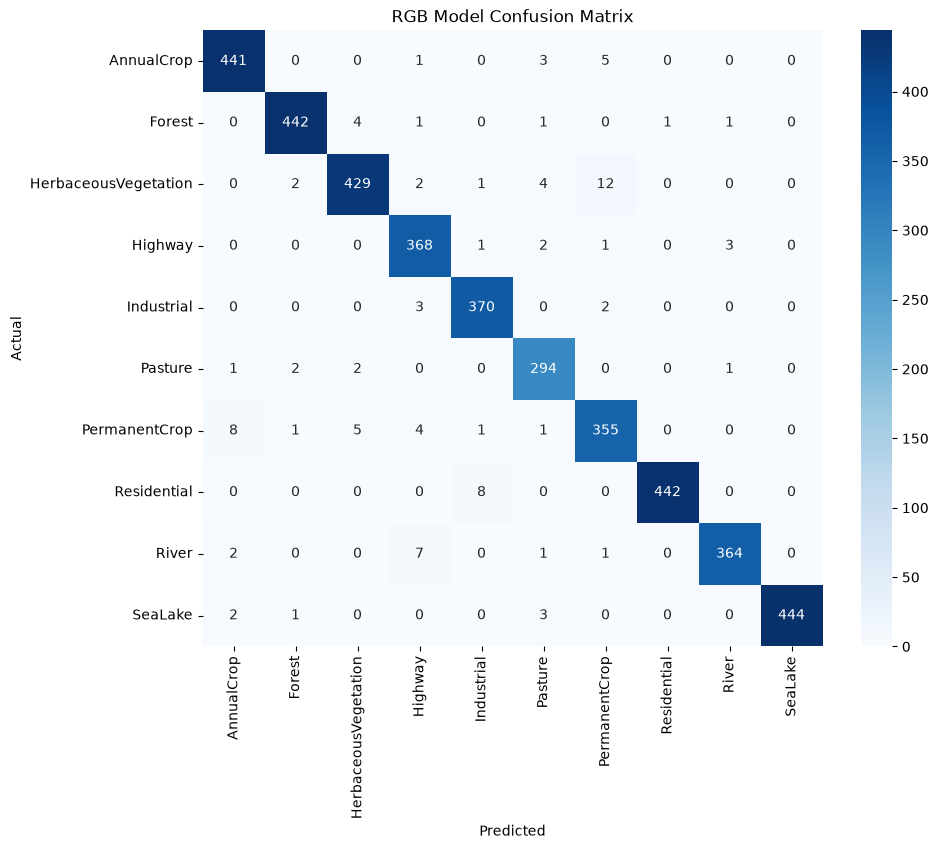

In [9]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=val_dataset.classes,
    yticklabels=val_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("RGB Model Confusion Matrix")

plt.show()

In [9]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=val_dataset.classes
    )
)

                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.98      0.98       450
              Forest       0.99      0.98      0.98       450
HerbaceousVegetation       0.97      0.95      0.96       450
             Highway       0.95      0.98      0.97       375
          Industrial       0.97      0.99      0.98       375
             Pasture       0.95      0.98      0.97       300
       PermanentCrop       0.94      0.95      0.95       375
         Residential       1.00      0.98      0.99       450
               River       0.99      0.97      0.98       375
             SeaLake       1.00      0.99      0.99       450

            accuracy                           0.98      4050
           macro avg       0.97      0.97      0.97      4050
        weighted avg       0.98      0.98      0.98      4050

